In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/Users/srisuphachawla/Downloads/stock_market_data.csv', header = [0,1])
df

Price       Close                                High              \
          Ticker        AAPL        MSFT        TSLA        AAPL        MSFT   
0           Date         NaN         NaN         NaN         NaN         NaN   
1     2018-01-02   40.341885   79.050354   21.368668   40.351254   79.381456   
2     2018-01-03   40.334866   79.418282   21.150000   40.878192   79.565441   
3     2018-01-04   40.522221   80.117271   20.974667   40.625266   80.623123   
4     2018-01-05   40.983578   81.110565   21.105333   41.070228   81.312906   
...          ...         ...         ...         ...         ...         ...   
2032  2026-02-02  270.010010  423.369995  421.809998  270.489990  430.739990   
2033  2026-02-03  269.480011  411.209991  421.959991  271.880005  422.049988   
2034  2026-02-04  276.489990  414.190002  406.010010  278.950012  419.799988   
2035  2026-02-05  275.910004  393.670013  397.209991  279.500000  408.299988   
2036  2026-02-06  278.119995  401.140015  411.109985  280.910004  401.790009   

                         Low                                Open              \
            TSLA        AAPL        MSFT        TSLA        AAPL        MSFT   
0            NaN         NaN         NaN         NaN         NaN         NaN   
1      21.474001   39.639309   78.636481   20.733334   39.850084   79.215905   
2      21.683332   40.271636   79.068788   21.036667   40.405124   79.151560   
3      21.236668   40.299739   79.620619   20.378668   40.407465   79.639010   
4      21.149332   40.526904   80.411572   20.799999   40.618239   80.623112   
...          ...         ...         ...         ...         ...         ...   
2032  427.149994  259.209991  422.250000  414.500000  260.029999  430.239990   
2033  428.559998  267.609985  408.559998  413.690002  269.200012  422.010010   
2034  423.899994  272.290009  409.239990  399.179993  272.290009  411.000000   
2035  402.100006  273.230011  392.320007  387.529999  278.130005  407.440002   
2036  414.549988  276.929993  392.920013  397.750000  277.119995  399.170013   

                       Volume                           
            TSLA         AAPL        MSFT         TSLA  
0            NaN          NaN         NaN          NaN  
1      20.799999  102223600.0  22483800.0   65283000.0  
2      21.400000  118071600.0  26061400.0   67822500.0  
3      20.858000   89738400.0  21912000.0  149194500.0  
4      21.108000   94640000.0  23407100.0   68868000.0  
...          ...          ...         ...          ...  
2032  421.290009   73913400.0  42219900.0   58739500.0  
2033  424.269989   64394700.0  61424100.0   56886500.0  
2034  420.459991   90545700.0  45012400.0   74606900.0  
2035  397.019989   52977400.0  66289200.0   72819800.0  
2036  400.869995   50420700.0  53403600.0   62559600.0  

[2037 rows x 16 columns]

# Pre-processesing to consider:
1. Ticker as column name
2. clean up the dates
3. remove the row Date since Nan

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2037 entries, 0 to 2036
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Price, Ticker)  2037 non-null   object 
 1   (Close, AAPL)    2036 non-null   float64
 2   (Close, MSFT)    2036 non-null   float64
 3   (Close, TSLA)    2036 non-null   float64
 4   (High, AAPL)     2036 non-null   float64
 5   (High, MSFT)     2036 non-null   float64
 6   (High, TSLA)     2036 non-null   float64
 7   (Low, AAPL)      2036 non-null   float64
 8   (Low, MSFT)      2036 non-null   float64
 9   (Low, TSLA)      2036 non-null   float64
 10  (Open, AAPL)     2036 non-null   float64
 11  (Open, MSFT)     2036 non-null   float64
 12  (Open, TSLA)     2036 non-null   float64
 13  (Volume, AAPL)   2036 non-null   float64
 14  (Volume, MSFT)   2036 non-null   float64
 15  (Volume, TSLA)   2036 non-null   float64
dtypes: float64(15), object(1)
memory usage: 254.8+ KB


In [4]:
# removing the faux date row
df = df.iloc[1:].copy()

In [5]:
# flattening columns temporarily for an easier reshape
df.columns = [
    f'{col[0]}_{col[1]}' if col[1] != '' else col[0] for col in df.columns
]
df

,Price_Ticker,Close_AAPL,Close_MSFT,Close_TSLA,High_AAPL,High_MSFT,High_TSLA,Low_AAPL,Low_MSFT,Low_TSLA,Open_AAPL,Open_MSFT,Open_TSLA,Volume_AAPL,Volume_MSFT,Volume_TSLA
1,2018-01-02,40.341885,79.050354,21.368668,40.351254,79.381456,21.474001,39.639309,78.636481,20.733334,39.850084,79.215905,20.799999,102223600.0,22483800.0,65283000.0
2,2018-01-03,40.334866,79.418282,21.150000,40.878192,79.565441,21.683332,40.271636,79.068788,21.036667,40.405124,79.151560,21.400000,118071600.0,26061400.0,67822500.0
3,2018-01-04,40.522221,80.117271,20.974667,40.625266,80.623123,21.236668,40.299739,79.620619,20.378668,40.407465,79.639010,20.858000,89738400.0,21912000.0,149194500.0
4,2018-01-05,40.983578,81.110565,21.105333,41.070228,81.312906,21.149332,40.526904,80.411572,20.799999,40.618239,80.623112,21.108000,94640000.0,23407100.0,68868000.0
5,2018-01-08,40.831341,81.193336,22.427334,41.126421,81.469257,22.468000,40.732977,80.567923,21.033333,40.831341,81.119757,21.066668,82271200.0,22113000.0,147891000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2032,2026-02-02,270.010010,423.369995,421.809998,270.489990,430.739990,427.149994,259.209991,422.250000,414.500000,260.029999,430.239990,421.290009,73913400.0,42219900.0,58739500.0
2033,2026-02-03,269.480011,411.209991,421.959991,271.880005,422.049988,428.559998,267.609985,408.559998,413.690002,269.200012,422.010010,424.269989,64394700.0,61424100.0,56886500.0
2034,2026-02-04,276.489990,414.190002,406.010010,278.950012,419.799988,423.899994,272.290009,409.239990,399.179993,272.290009,411.000000,420.459991,90545700.0,45012400.0,74606900.0
2035,2026-02-05,275.910004,393.670013,397.209991,279.500000,408.299988,402.100006,273.230011,392.320007,387.529999,278.130005,407.440002,397.019989,52977400.0,66289200.0,72819800.0


In [6]:
# melt and organize
df_long = df.melt(
    id_vars = ['Price_Ticker'],
    var_name = 'Feature_Ticker',
    value_name = 'Value'
)
df_long[['Feature', 'Ticker']] = df_long['Feature_Ticker'].str.split('_', expand = True)

df_final = df_long.pivot_table(
    index = ['Price_Ticker', 'Ticker'],
    columns = 'Feature',    
    values = 'Value'
).reset_index()


df_final


Feature,Price_Ticker,Ticker,Close,High,Low,Open,Volume
0,2018-01-02,AAPL,40.341885,40.351254,39.639309,39.850084,102223600.0
1,2018-01-02,MSFT,79.050354,79.381456,78.636481,79.215905,22483800.0
2,2018-01-02,TSLA,21.368668,21.474001,20.733334,20.799999,65283000.0
3,2018-01-03,AAPL,40.334866,40.878192,40.271636,40.405124,118071600.0
4,2018-01-03,MSFT,79.418282,79.565441,79.068788,79.151560,26061400.0
...,...,...,...,...,...,...,...
6103,2026-02-05,MSFT,393.670013,408.299988,392.320007,407.440002,66289200.0
6104,2026-02-05,TSLA,397.209991,402.100006,387.529999,397.019989,72819800.0
6105,2026-02-06,AAPL,278.119995,280.910004,276.929993,277.119995,50420700.0
6106,2026-02-06,MSFT,401.140015,401.790009,392.920013,399.170013,53403600.0


### Dataset Overview


In [26]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6108 entries, 0 to 6107
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price_Ticker  6108 non-null   object 
 1   Ticker        6108 non-null   object 
 2   Close         6108 non-null   float64
 3   High          6108 non-null   float64
 4   Low           6108 non-null   float64
 5   Open          6108 non-null   float64
 6   Volume        6108 non-null   float64
dtypes: float64(5), object(2)
memory usage: 334.2+ KB


In [27]:
df_final.describe()

Feature,Close,High,Low,Open,Volume
count,6108.000000,6108.000000,6108.000000,6108.000000,6.108000e+03
mean,196.482501,199.148652,193.641184,196.448584,8.168167e+07
std,123.548497,125.076232,121.986177,123.625906,6.746242e+07
min,11.931333,12.445333,11.799333,12.073333,5.855900e+06
25%,101.065298,102.224085,99.755783,101.053760,3.141062e+07
50%,186.265907,188.476360,182.780993,185.890889,6.745025e+07
75%,267.265007,270.795755,261.788229,267.010002,1.067669e+08
max,541.057373,553.502444,539.759814,553.283183,9.140820e+08


In [28]:
# checking for duplicates

df_final.duplicated().sum()

np.int64(0)

## Univariate analysis

In [14]:
numerical = df_final.select_dtypes(include=['float64']).columns
categorical = df_final.select_dtypes(include=['object']).columns

In [24]:
desc_stats = df_final[numerical].describe().T

desc_stats.round(2)

,count,mean,std,min,25%,50%,75%,max
Feature,,,,,,,,
Close,6108.0,196.48,123.55,11.93,101.07,186.27,2.672700e+02,5.410600e+02
High,6108.0,199.15,125.08,12.45,102.22,188.48,2.708000e+02,5.535000e+02
Low,6108.0,193.64,121.99,11.80,99.76,182.78,2.617900e+02,5.397600e+02
Open,6108.0,196.45,123.63,12.07,101.05,185.89,2.670100e+02,5.532800e+02
Volume,6108.0,81681672.07,67462420.18,5855900.00,31410625.00,67450250.00,1.067669e+08,9.140820e+08


In [29]:
desc_stats['range'] = desc_stats['max'] - desc_stats['min']
desc_stats['IQR'] = desc_stats['75%'] - desc_stats['25%']
desc_stats['skenewss'] = df_final[numerical].skew()
desc_stats['kurtosis'] = df_final[numerical].kurtosis()

desc_stats.round(2)

,count,mean,std,min,25%,50%,75%,max,range,IQR,skenewss,kurtosis
Feature,,,,,,,,,,,,
Close,6108.0,196.48,123.55,11.93,101.07,186.27,2.672700e+02,5.410600e+02,5.291300e+02,166.20,0.53,-0.32
High,6108.0,199.15,125.08,12.45,102.22,188.48,2.708000e+02,5.535000e+02,5.410600e+02,168.57,0.52,-0.35
Low,6108.0,193.64,121.99,11.80,99.76,182.78,2.617900e+02,5.397600e+02,5.279600e+02,162.03,0.55,-0.29
Open,6108.0,196.45,123.63,12.07,101.05,185.89,2.670100e+02,5.532800e+02,5.412100e+02,165.96,0.54,-0.31
Volume,6108.0,81681672.07,67462420.18,5855900.00,31410625.00,67450250.00,1.067669e+08,9.140820e+08,9.082261e+08,75356300.00,2.51,12.46


In [31]:
for col in numerical:
    print(f"\n{'=' * 60}")
    print(f"Variable: {col.upper()}")
    print(f"{'=' * 60}")

    print("\n📊 Measures of Central Tendency:")
    print(f"   Mean:     ${df_final[col].mean():.2f}" if col in ['total_bill', 'tip'] else f"   Mean:     {df_final[col].mean():.2f}")
    print(f"   Median:   ${df_final[col].median():.2f}" if col in ['total_bill', 'tip'] else f"   Median:   {df_final[col].median():.2f}")
    print(f"   Mode:     {df_final[col].mode().values[0]:.2f}")

    print("\n📏 Measures of Spread:")
    print(f"   Range:    {df_final[col].max() - df_final[col].min():.2f}")
    print(f"   IQR:      {df_final[col].quantile(0.75) - df_final[col].quantile(0.25):.2f}")
    print(f"   Std Dev:  {df_final[col].std():.2f}")
    print(f"   Variance: {df_final[col].var():.2f}")

    print("\n📈 Measures of Shape:")
    print(f"   Skewness: {df_final[col].skew():.2f}", end="")
    if df_final[col].skew() > 0.5:
        print(" (Right-skewed/Positively skewed)")
    elif df_final[col].skew() < -0.5:
        print(" (Left-skewed/Negatively skewed)")
    else:
        print(" (Approximately symmetric)")

    print(f"   Kurtosis: {df_final[col].kurtosis():.2f}", end="")
    if df_final[col].kurtosis() > 3:
        print(" (Heavy-tailed)")
    elif df_final[col].kurtosis() < 3:
        print(" (Light-tailed)")
    else:
        print(" (Normal-tailed)")


Variable: CLOSE

📊 Measures of Central Tendency:
   Mean:     196.48
   Median:   186.27
   Mode:     14.64

📏 Measures of Spread:
   Range:    529.13
   IQR:      166.20
   Std Dev:  123.55
   Variance: 15264.23

📈 Measures of Shape:
   Skewness: 0.53 (Right-skewed/Positively skewed)
   Kurtosis: -0.32 (Light-tailed)

Variable: HIGH

📊 Measures of Central Tendency:
   Mean:     199.15
   Median:   188.48
   Mode:     20.31

📏 Measures of Spread:
   Range:    541.06
   IQR:      168.57
   Std Dev:  125.08
   Variance: 15644.06

📈 Measures of Shape:
   Skewness: 0.52 (Right-skewed/Positively skewed)
   Kurtosis: -0.35 (Light-tailed)

Variable: LOW

📊 Measures of Central Tendency:
   Mean:     193.64
   Median:   182.78
   Mode:     18.70

📏 Measures of Spread:
   Range:    527.96
   IQR:      162.03
   Std Dev:  121.99
   Variance: 14880.63

📈 Measures of Shape:
   Skewness: 0.55 (Right-skewed/Positively skewed)
   Kurtosis: -0.29 (Light-tailed)

Variable: OPEN

📊 Measures of Central T

### Distribution Analysis

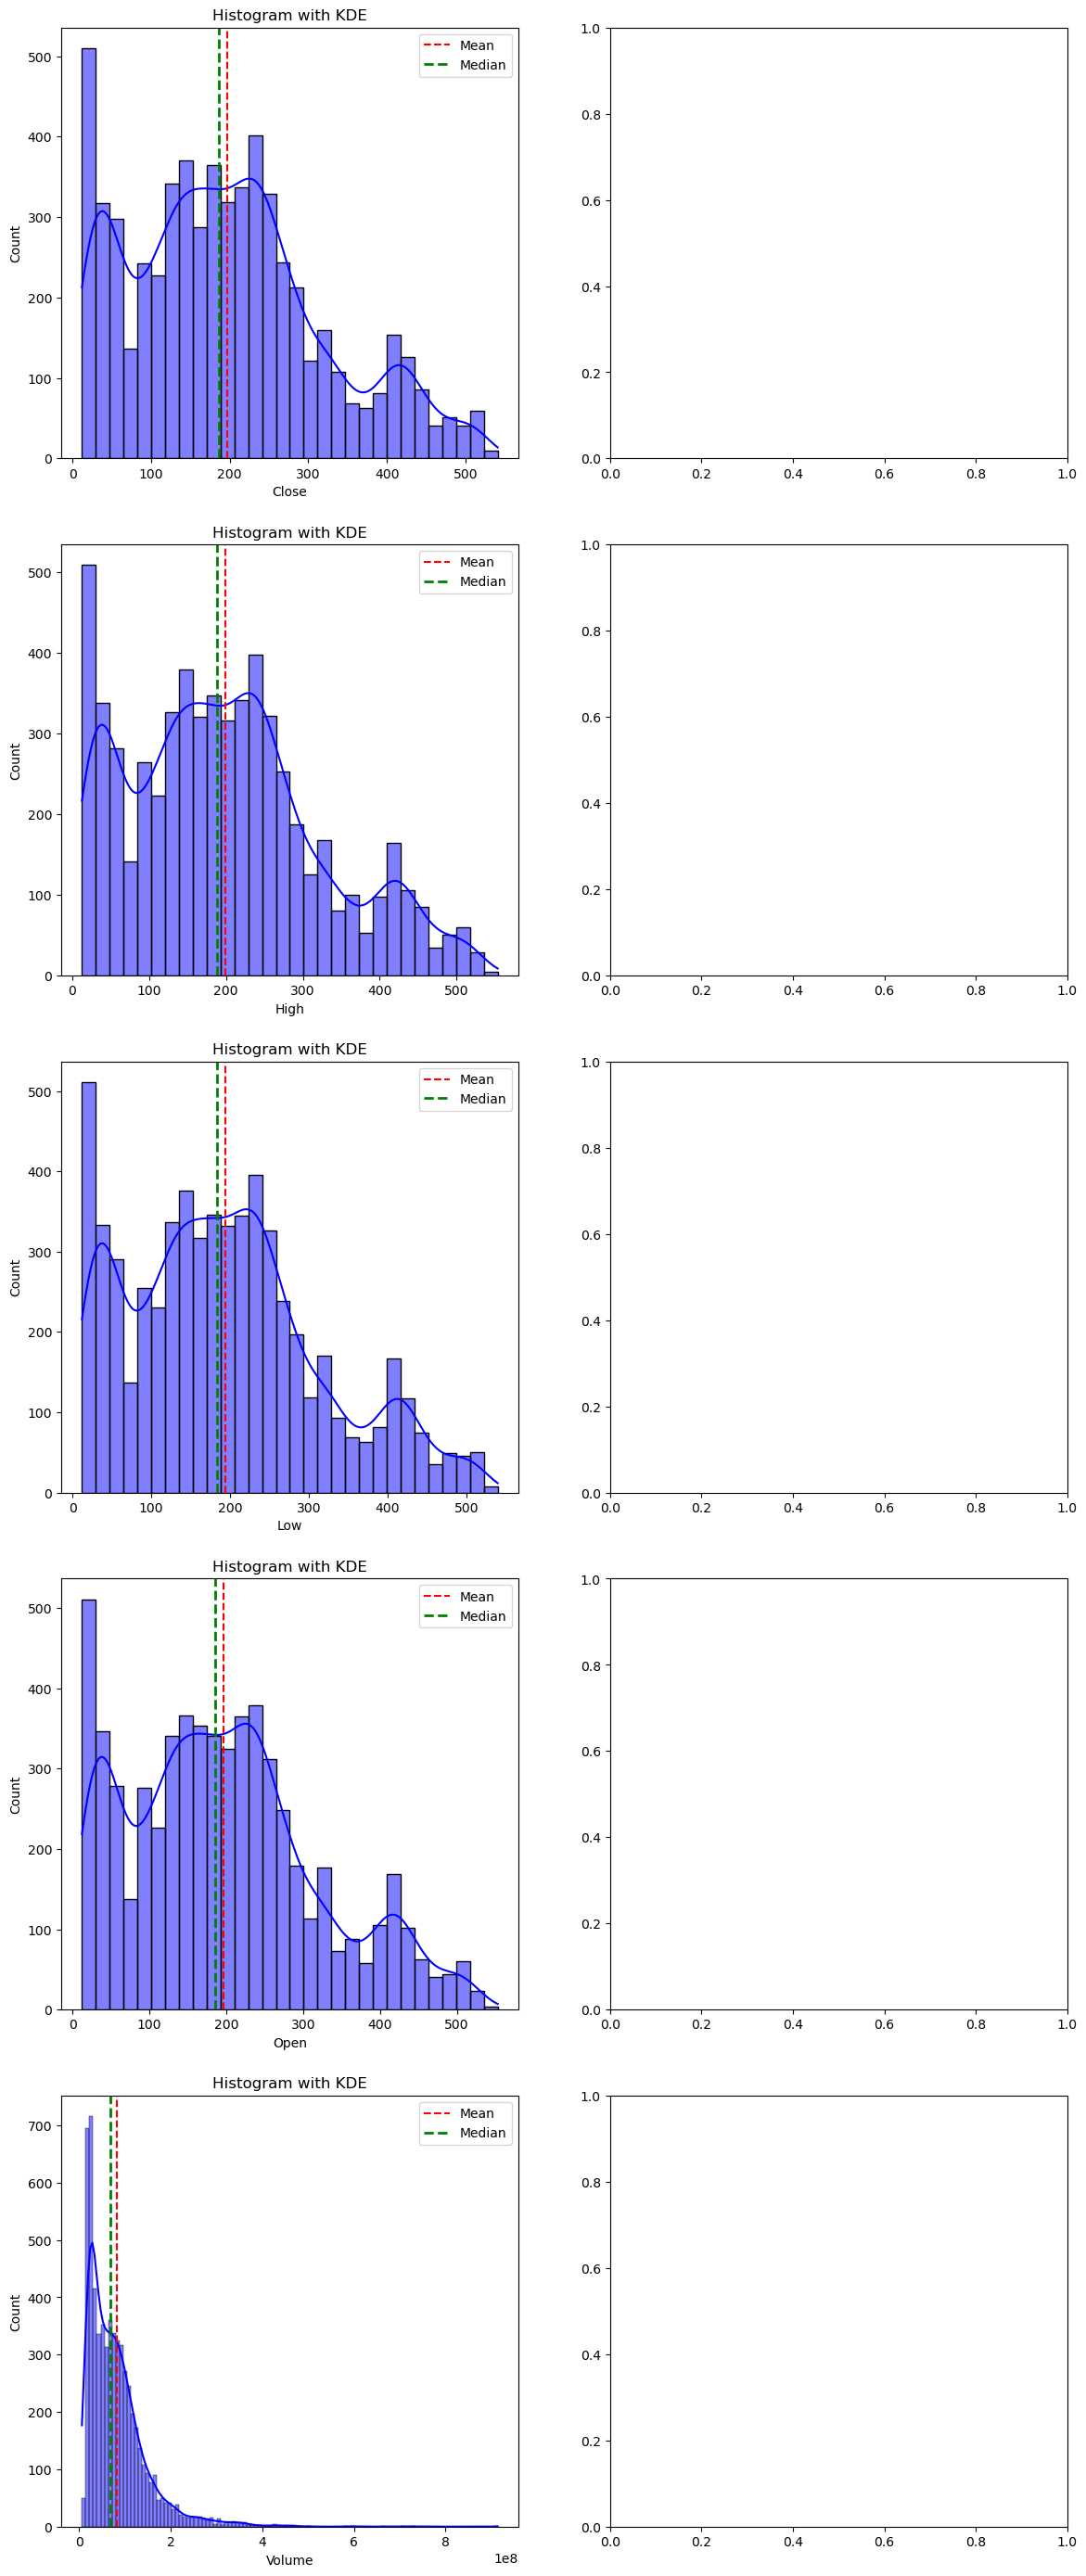

In [50]:
figs, axes = plt.subplots(len(numerical), 2, figsize=(14, 7*len(numerical)))
for i, j in enumerate(numerical):
    _ = sns.histplot(data=df_final, x = j, kde= True, ax=axes[i, 0], color = 'blue')
    axes[i, 0].axvline(df_final[j].mean(), color = 'red', linestyle = '--', label = 'Mean')
    axes[i, 0].axvline(df_final[j].median(), color='green', linestyle='--', linewidth=2, label='Median')
    axes[i, 0].set_title('Histogram with KDE')
    axes[i, 0].legend()


plt.tight_layout
plt.show()